Data generation for the test!

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import os

torch.manual_seed(42)
np.random.seed(42)

def generate_data(n_samples=2000, noise=0.01):
    # Uniform in [-1, 1]^2
    x = torch.rand(n_samples, 2) * 2 - 1
    # The hard function
    y = torch.exp(torch.sin(torch.pi * x[:, 0]) + x[:, 1]**2)
    y = y.unsqueeze(1) + noise * torch.randn(n_samples, 1)
    return x, y

x, y = generate_data()

# Create directory one level up
os.makedirs("../data", exist_ok=True)

# Serialize tensors to disk one level up
torch.save(x, "../data/x_data.pt")
torch.save(y, "../data/y_data.pt")

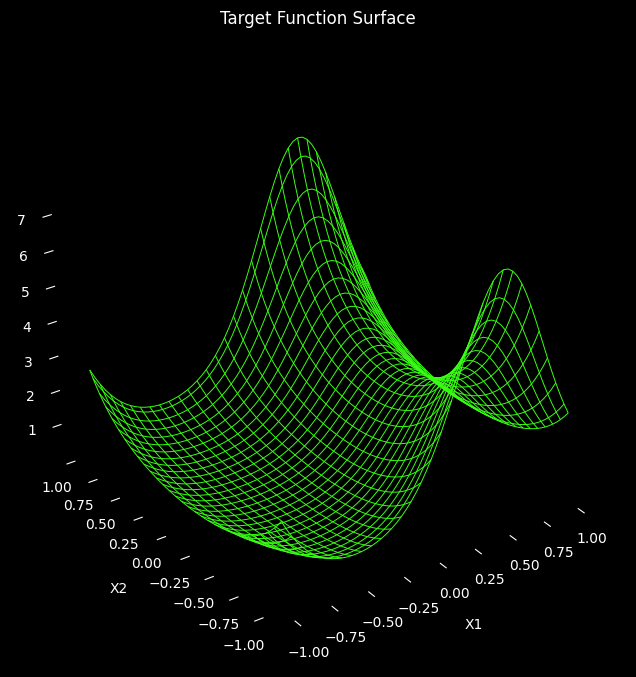

In [7]:
#-----PLOT-----#

# 1. Define the grid space over the domain [-1, 1]^2
x1_vals = np.linspace(-1, 1, 60)
x2_vals = np.linspace(-1, 1, 60)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# 2. Compute the true function (noiseless)
# f(x_1, x_2) = exp(sin(pi * x_1) + x_2^2)
Y = np.exp(np.sin(np.pi * X1) + X2**2)

# 3. Configure the aesthetic environment (Black background)
fig = plt.figure(figsize=(10, 8), facecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')

# 4. Plot the surface as a neon green wireframe
neon_green = '#39FF14'
ax.plot_wireframe(X1, X2, Y, color=neon_green, linewidth=0.7)

# 5. Format axes to maintain the minimalist dark theme
# Remove pane fill colors
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Set pane edge colors to black to hide the default bounding box
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

# Turn off the default background axis grid lines
ax.grid(False)

# Set labels and tick colors to white for contrast
ax.tick_params(colors='white')
ax.set_xlabel('X1', color='white', labelpad=10)
ax.set_ylabel('X2', color='white', labelpad=10)
ax.set_zlabel('Y', color='white', labelpad=10)

ax.set_title(r'Target Function Surface', color='white', pad=20)

# Adjust viewing angle for optimal visibility of the peak and trough
ax.view_init(elev=30, azim=-125)

plt.show()